# A robust script to take 2D or 3D output from CESM as well as 2D or 3D ouutput from obs. and reanalysis to:plot
### 1. Zonal Averages for 1D (done)
### 2. Lat-Lon averages for 2D (done)
### 3. Zonal average for 3D
### 4. Lat-lon slices for 2D on a pressure surface 
### 5. Column regional averages
### 6. Meridional slice avaregs (default 5S-5N)
### 7. Meridional 2D slice averages

In [11]:
import xarray as xr
import matplotlib.pyplot as mp

import glob as glob
import os as os
from pathlib import Path

import cartopy.crs as ccrs

import importlib
import general_cesm_plot_utils as mypy_utils
import general_vars_cases_figname as mypy_cases

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [13]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=1,
    memory="8GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=8)
client = Client(cluster)

client

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38677 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/38677/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/38677/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.197:40211,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/38677/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [16]:
# Replace with your actual file paths and variable name

# Import
importlib.reload(mypy_cases) # Required because I am constantly editing scam_func.py



dir0 = '/glade/derecho/scratch/rneale/archive/'
dir_climo = '/glade/campaign/cgd/amp/amwg/climo/'
dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'
dir_fig = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/AMWG2026/'



seas = 'DJF'

lfcase = 1  # Plot CAM and not CESM cases.
lanom_plot = True  # Will plot the first case, and then subsequence cases plots the difference from ths first case


# Options [lat,latlon,latpres]
plot_type = "latlon" ; lon_ave = [0.,360.]
#plot_type = "lat" ; lon_ave = [230,270]

mask_ocn = False

pregion = 'Tropics' # Options [Global ,LabSea, IO, US, SAm, Aus, TP, WP, IndoPac, Tropics, EPac,NPolar]
#pregion = 'Boreal'


vproc = 'pvint'
vproc = 'vint'


dcases,var,obs_cases,fig_pref = mypy_cases.get_case_all(lfcase)



case_names = list(dcases.keys())
cases = [v for v in dcases.values()]



vmask_ocn = ['PRECT','LHFLX','SHFLX','TMQ','TAUY','TAUX'] # These are masked just over ocean by default


cases = obs_cases+cases if obs_cases != [''] else cases
case_names = obs_cases+case_names if obs_cases != [''] else case_names
nobs = len(obs_cases) if obs_cases != [''] else 0


ncases = len(cases)
pcases = ncases


obs_set = ['GPCP','TRMM','CERES2','CERES-EBAF','ERBE','ERAI','JRA25','MERRA','LARYEA','WHOI','NVAP','ERS','SSMI','HadISST_PI','HadSST_PD']


# Set plot set logicals

if plot_type not in ['lat','latlon','latpres'] :
    print(" **** UNRECOGNIZED PLOT TYPE. ALLOWED TYPES ARE - ['lat','latlon','latpres']")

pregions = ['NPolar','SPolar','LabSea', 'IO', 'US', 'SAm', 'Aus', 'TP','WP', 'Tropics','IndoPac','EPac']
if pregion not in pregions:
    print(" **** UNRECOGNIZED PLOT REGION. ALLOWED REGIONS ARE ...")        
    print(pregions) 
                   
if 'plot_sub_nums' not in locals():
    plot_sub_nums = list(range(ncases))





>>> Plotting Summary <<< 
 *** Variable =  PRECT
 *** Region  =  Tropics
 *** Domain = latlon
 *** Anomalies = True
 *** Season = DJF

>>> Cases <<<
  - TRMM
  - f.e20.FHIST.f09_f09.cesm2_1.001
  - f.cam6_4_130.FLTHIST_ne30.cam7-tpert.001
  - f.cam6_4_089.FLTHIST_ne30.cam7_zm_tiedke2K.001
  - f.cam6_4_130.FLTHIST_ne30.cam7-tpert.010
  - f.cam6_4_130.FLTHIST_ne30.cam7-tpert.012
  - f.cam6_4_130.FLTHIST_ne30.cam7-tpert.014
  - f.cam6_4_130.FLTHIST_ne30.cam7-tpert.015
  - f.cam6_4_130.FLTHIST_ne30.cam7-tpert.016

Case -  [1]  of  [9]  -  TRMM 
 - Opening case dataset -  Observations
 - Configuring variables -
 - Processing variable ready for plotting -
 - Plotting -

Case -  [2]  of  [9]  -  f.e20.FHIST.f09_f09.cesm2_1.001 
 - Opening case dataset -  I have them
 - Configuring variables -
 - Processing variable ready for plotting -
 - Plotting -

Case -  [3]  of  [9]  -  f.cam6_4_130.FLTHIST_ne30.cam7-tpert.001 
 - Opening case dataset -  I have them
 - Configuring variables -
 - Process

/glade/work/rneale/git/python-scripts/CAM7_CESM3_dev/AMWG2026/general_cesm_plot_utils.py:292: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.97])



************
* Finished *
************



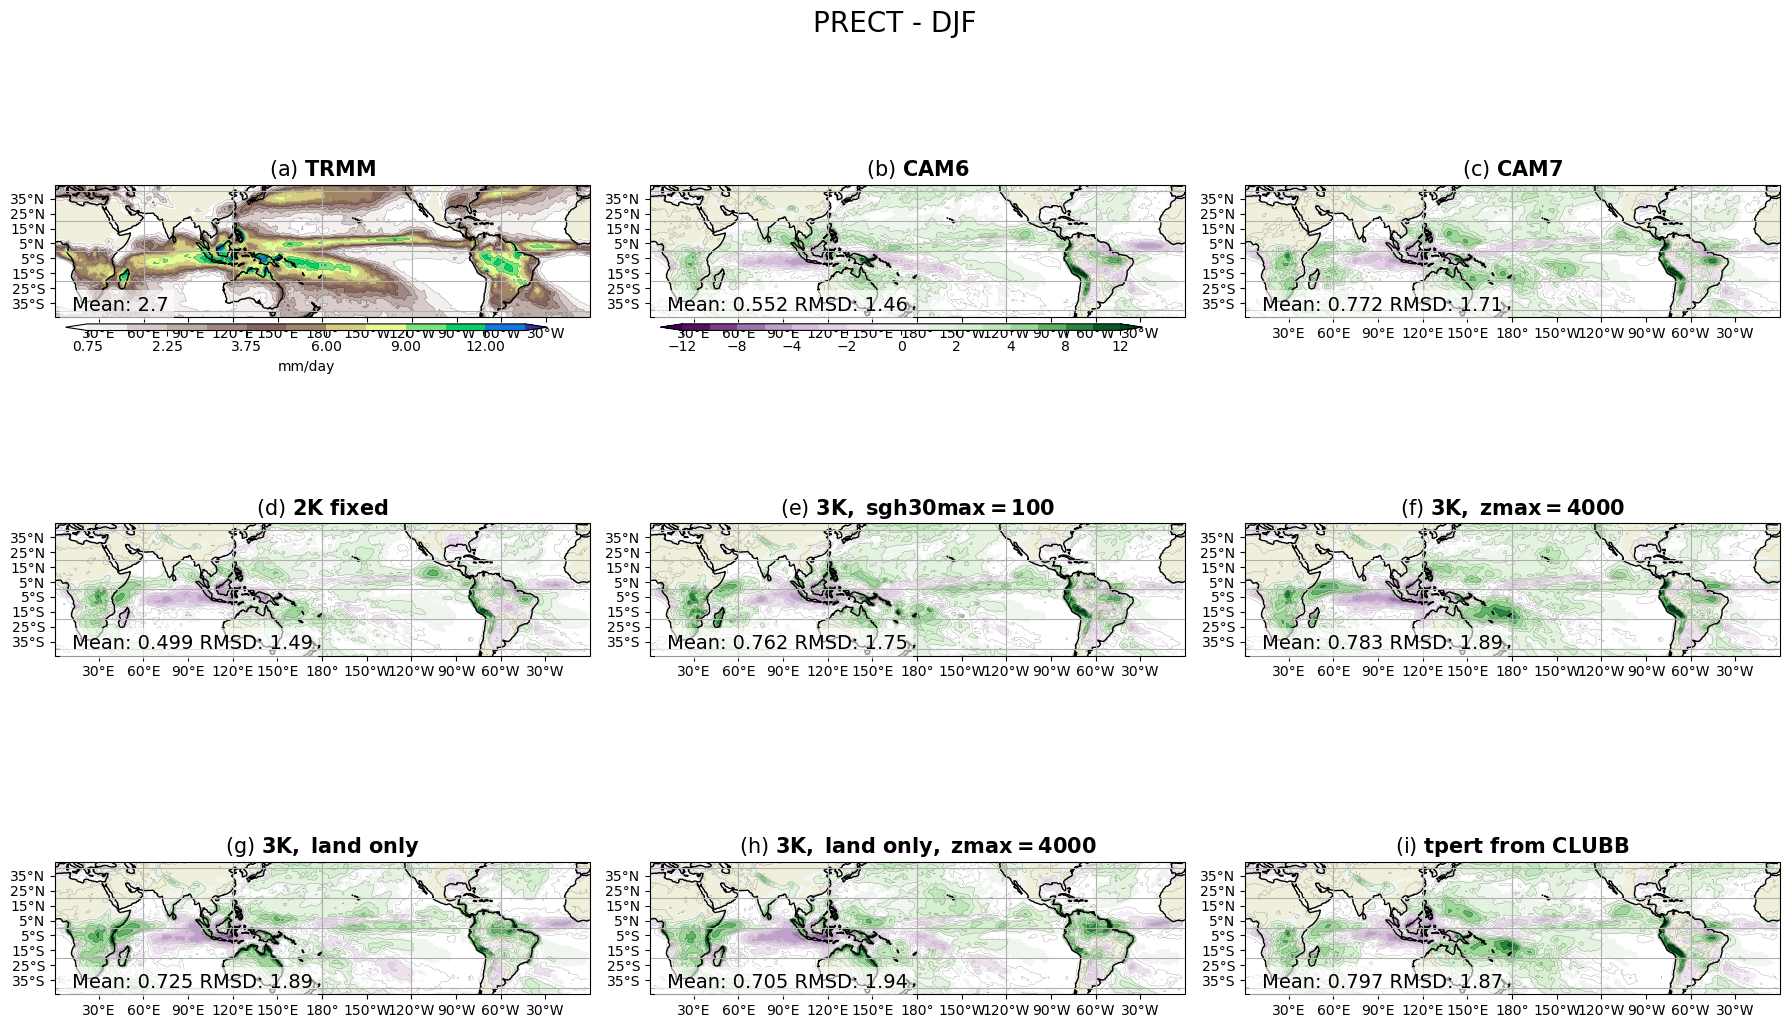

In [17]:

%autoreload 2

## Need to tie the below up into a function

match plot_type:
    case 'lat':
        nrows = 1 
        ncols = 1
        fig, ax = mp.subplots(figsize=[12, 8])    
    
    case 'latlon':
        nrows = 3
        ncols = 3

        ccrs_preg = ccrs.Robinson(central_longitude=180.) if pregion == 'Global' else ccrs.PlateCarree(central_longitude=180.)
        
        if pregion in ['NPolar','SPolar']:

            fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*5, nrows*6.],
                           subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=0.)}, constrained_layout=True)  
        
        else:
        
            fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*6, nrows*4],
                           subplot_kw={'projection': ccrs_preg}, constrained_layout=True)    
        ax = axs.flatten()
    
    case 'latpres':
    
        nrows = 3
        ncols = 3
        
        fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*6, nrows*5], constrained_layout=True)
        ax = axs.flatten()

# Total number of sub-panels reserved
nsplots = nrows*ncols

if nrows*ncols > ncases : print("** Too many panels for ncases")
if nrows*ncols < ncases : print("** Too few  panels for ncases")


print('')
print('>>> Plotting Summary <<< ')

print(' *** Variable = ',var)
print(' *** Region  = ',pregion)
print(' *** Domain =',plot_type)
print(' *** Anomalies =',lanom_plot)
print(' *** Season =',seas)
print('')
print('>>> Cases <<<')

fcases = '\n'.join(f"  - {item}" for item in cases)
print(fcases)





# Set default that var_save isn't needed
var_save = None



















''' 
    LOOP FOR PLOTS (Could include empty plots) 
'''

nskip_panel = -1
splots = list(range(ncases))


if nskip_panel >= 0:
    ax[nskip_panel].set_visible(False)


for icase, case in enumerate(cases[0:pcases]):    

    isplot = splots[icase]
    
    print('')
    print('\033[4mCase - ',[icase+1],' of ',[ncases],' - ',case,'\033[0m' )
    cname = case_names[icase]
    llast_case = icase == ncases-1 # Is this the last case.

    is_obs = case in obs_set

# Obs and 2 climo types file selection.
    if is_obs:
        case_file = dir_obs+case+'_'+seas+'_climo.nc'  
        climo_loc = 'Observations'
    else:
        case_dir = Path(dir0+case+'/climo') # Do I have the climo files
        
        if case_dir.is_dir():
            climo_loc = 'I have them'
            case_file = dir0+case+'/climo/'+case+'_'+seas+'_climo.nc'
        else:  # Sort directories to give the newest climo sets.
            climo_loc = 'AMWG has them'
            case_file = glob.glob(dir_climo+case+'/*/'+case+'_'+var+'_climo.nc')
            if len(case_file) != 0: case_file = sorted(case_file,key=os.path.getmtime, reverse=True)[0]
                    

    
# Open dataset

    print(' - Opening case dataset - ',climo_loc)

    ds = xr.open_dataset(case_file,decode_times = False, chunks={},engine='netcdf4')
   
# Extract variable/obs. specific information

    var_info = mypy_utils.set_var_params(ds,var,case)
   

    var_from_file = var_info[var][case][1] if is_obs else var

    vscale = var_info[var][case][0]      if is_obs else var_info[var]['vscale']
    vunits = var_info[var]['vunits']
    voffset = 0.

    
    if not is_obs:
        voffset = var_info[var]['voffset'] if 'voffset' in var_info[var] else 0.

    
# Grab variable or derived variable from file(s)

    var_in,ds = mypy_utils.getvar_derived(ds,var_from_file,seas)
    var_in = var_in*vscale+voffset
  
  
    


# Masking option (if in variable masking array)

    if var in vmask_ocn and mask_ocn : var_in = mypy_utils.apply_land_mask(ds,var_in)
    
# Anomalies from icase = 0?

    print(' - Configuring variables -')
   
    var_plot, var_save = mypy_utils.var_forplot(ds,var_in,var,var_save,icase,lanom_plot,is_obs,vproc)
   
    case_stats = mypy_utils.case_stats_calc(var_plot,var_save,pregion,lanom_plot,icase) # Calculate some stats (Mean/Std/Corr. for now).    

    
# Plotting options

    print(' - Plotting -')
    
    if plot_type in ['lat','lon']:
        zonal_mean = var_plot.sel(lat=slice(-60, 60)).sel(lon=slice(*lon_ave)).mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_lat(icase,case,obs_set,nobs)
        mypy_utils.plot_lat(ax,fig,icase,var,zonal_mean,vunits,cname,seas,mask_ocn,lanom_plot,llast_case,params_plot)

    if plot_type == 'latlon':
        params_plot = mypy_utils.set_params_latlon(icase,ncases,var,obs_set,lanom_plot)
        mypy_utils.plot_latlon(ax[isplot],fig,icase,var,var_plot,case_stats,vunits,cname,seas,pregion,mask_ocn,lanom_plot,llast_case,params_plot)

    if plot_type in ['latpres','pres']:
        zonal_mean = var_plot.mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_latpres(icase,ncases,var,obs_set,lanom_plot)
        mypy_utils.plot_latpres(ax[isplot],fig,icase,zonal_mean,vunits,cname,seas,lanom_plot,llast_case,params_plot)


#fig.suptitle(var+' - '+seas, fontweight='bold', fontsize=20)


# Set unused ax[icase] to blank
for ix in range(ncases,nrows*ncols): ax[ix].set_visible(False)


# png output file


print('')
print('************')
print('* Finished *')
print('************')
print('')

panom = 'anom_' if lanom_plot else ''
panom = panom+obs_cases[0]+'_' if obs_cases[0] != '' else ''

fig_file = dir_fig+fig_pref+'_'+var+'_'+seas+'_'+pregion+'_'+panom+plot_type+'_panel.png'




fig.savefig(fig_file)
fig.show()

